# BST（二叉搜索树）操作与删除策略分析

本笔记涵盖三个问题：
1. **题1**：从空树开始构建 BST，依次插入序列 `[50, 30, 70, 20, 40, 60, 80]`，画出最终 BST
2. **题2**：删除根结点 50，分别用"中序前驱"和"中序后继"两种策略，画出结果
3. **题3**：在真正的项目里使用的是哪个策略？为什么？

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm

# ========== 配置中文字体 ==========
# 指定使用微软雅黑等中文字体，解决图表中文显示为方块的问题
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'STXihei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题
# 重建字体缓存，确保字体生效
fm._load_fontmanager(try_read_cache=False)
print('当前中文字体配置:', plt.rcParams['font.sans-serif'][:2])

# ========== 定义二叉树结点 ==========
class TreeNode:
    def __init__(self, val):
        self.val = val
        self.left = None
        self.right = None

# ========== 定义二叉搜索树 ==========
class BST:
    def __init__(self):
        self.root = None

    def insert(self, val):
        """插入一个值到 BST 中"""
        if self.root is None:
            self.root = TreeNode(val)
        else:
            self._insert(self.root, val)

    def _insert(self, node, val):
        if val < node.val:
            if node.left is None:
                node.left = TreeNode(val)
            else:
                self._insert(node.left, val)
        elif val > node.val:
            if node.right is None:
                node.right = TreeNode(val)
            else:
                self._insert(node.right, val)
        # 相等则忽略（BST 不允许重复）

    def inorder(self):
        """中序遍历，返回有序列表"""
        result = []
        self._inorder(self.root, result)
        return result

    def _inorder(self, node, result):
        if node:
            self._inorder(node.left, result)
            result.append(node.val)
            self._inorder(node.right, result)

    def find_min(self, node):
        """找子树的最小值结点"""
        current = node
        while current.left:
            current = current.left
        return current

    def find_max(self, node):
        """找子树的最大值结点"""
        current = node
        while current.right:
            current = current.right
        return current

    def delete_with_predecessor(self, val):
        """删除结点 —— 使用中序前驱策略"""
        self.root = self._delete_pre(self.root, val)

    def _delete_pre(self, node, val):
        if node is None:
            return None
        if val < node.val:
            node.left = self._delete_pre(node.left, val)
        elif val > node.val:
            node.right = self._delete_pre(node.right, val)
        else:
            # 找到了要删除的结点
            # 情况1&2: 只有一个孩子或无孩子
            if node.left is None:
                return node.right
            if node.right is None:
                return node.left
            # 情况3: 有两个孩子 —— 使用中序前驱
            predecessor = self.find_max(node.left)
            node.val = predecessor.val
            node.left = self._delete_pre(node.left, predecessor.val)
        return node

    def delete_with_successor(self, val):
        """删除结点 —— 使用中序后继策略"""
        self.root = self._delete_suc(self.root, val)

    def _delete_suc(self, node, val):
        if node is None:
            return None
        if val < node.val:
            node.left = self._delete_suc(node.left, val)
        elif val > node.val:
            node.right = self._delete_suc(node.right, val)
        else:
            # 找到了要删除的结点
            if node.left is None:
                return node.right
            if node.right is None:
                return node.left
            # 情况3: 有两个孩子 —— 使用中序后继
            successor = self.find_min(node.right)
            node.val = successor.val
            node.right = self._delete_suc(node.right, successor.val)
        return node

    def copy(self):
        """深拷贝一棵树"""
        new_bst = BST()
        new_bst.root = self._copy_node(self.root)
        return new_bst

    def _copy_node(self, node):
        if node is None:
            return None
        new_node = TreeNode(node.val)
        new_node.left = self._copy_node(node.left)
        new_node.right = self._copy_node(node.right)
        return new_node

print('✅ TreeNode 和 BST 类定义完成')

当前中文字体配置: ['Microsoft YaHei', 'SimHei']
✅ TreeNode 和 BST 类定义完成


In [2]:
# ========== 树的可视化函数 ==========
def get_tree_depth(node):
    """获取树的深度"""
    if node is None:
        return 0
    return 1 + max(get_tree_depth(node.left), get_tree_depth(node.right))

def get_node_positions(node, depth=0, left_bound=0, right_bound=100, positions=None):
    """递归计算每个结点的坐标"""
    if positions is None:
        positions = {}
    if node is None:
        return positions
    x = (left_bound + right_bound) / 2
    y = -depth  # 从上到下
    positions[node] = (x, y, node.val)
    get_node_positions(node.left, depth + 1, left_bound, x, positions)
    get_node_positions(node.right, depth + 1, x, right_bound, positions)
    return positions

def draw_bst(bst, title="BST", ax=None, highlight_val=None):
    """使用 matplotlib 绘制 BST"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    if bst.root is None:
        ax.text(0.5, 0.5, "空树", ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.axis('off')
        return

    positions = get_node_positions(bst.root, left_bound=0, right_bound=100)

    # 画边
    def draw_edges(node):
        if node is None:
            return
        x, y, _ = positions[node]
        if node.left:
            xl, yl, _ = positions[node.left]
            ax.plot([x, xl], [y, yl], 'k-', linewidth=1.5, alpha=0.7)
            draw_edges(node.left)
        if node.right:
            xr, yr, _ = positions[node.right]
            ax.plot([x, xr], [y, yr], 'k-', linewidth=1.5, alpha=0.7)
            draw_edges(node.right)
    draw_edges(bst.root)

    # 画结点
    for node, (x, y, val) in positions.items():
        color = '#FF6B6B' if val == highlight_val else '#4ECDC4'
        edge_color = '#C0392B' if val == highlight_val else '#2C3E50'
        circle = mpatches.Circle((x, y), 4.5, facecolor=color, edgecolor=edge_color,
                                  linewidth=2.5, zorder=2)
        ax.add_patch(circle)
        ax.text(x, y, str(val), ha='center', va='center', fontsize=11,
               fontweight='bold', color='white', zorder=3)

    # 设置画布
    depth = get_tree_depth(bst.root)
    ax.set_xlim(-5, 105)
    ax.set_ylim(-depth - 1, 1)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

print('✅ 可视化函数定义完成')

✅ 可视化函数定义完成


---
## 题1：构建 BST

从空树开始，依次插入序列 `[50, 30, 70, 20, 40, 60, 80]`，画出最终 BST。

### 插入过程分析

| 步骤 | 插入值 | 说明 |
|------|--------|------|
| 1 | 50 | 空树，50 成为根结点 |
| 2 | 30 | 30 < 50，成为 50 的左孩子 |
| 3 | 70 | 70 > 50，成为 50 的右孩子 |
| 4 | 20 | 20 < 50 → 左；20 < 30，成为 30 的左孩子 |
| 5 | 40 | 40 < 50 → 左；40 > 30，成为 30 的右孩子 |
| 6 | 60 | 60 > 50 → 右；60 < 70，成为 70 的左孩子 |
| 7 | 80 | 80 > 50 → 右；80 > 70，成为 70 的右孩子 |

最终得到一棵**平衡的 BST**（左右子树高度差为 0）。

插入序列: [50, 30, 70, 20, 40, 60, 80]
  插入 50 → 中序遍历: [50]
  插入 30 → 中序遍历: [30, 50]
  插入 70 → 中序遍历: [30, 50, 70]
  插入 20 → 中序遍历: [20, 30, 50, 70]
  插入 40 → 中序遍历: [20, 30, 40, 50, 70]
  插入 60 → 中序遍历: [20, 30, 40, 50, 60, 70]
  插入 80 → 中序遍历: [20, 30, 40, 50, 60, 70, 80]

最终中序遍历（验证 BST 性质）: [20, 30, 40, 50, 60, 70, 80]
树深度: 3


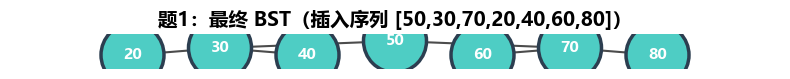

In [3]:
# ========== 题1：构建 BST ==========
bst = BST()
sequence = [50, 30, 70, 20, 40, 60, 80]

print("插入序列:", sequence)
for val in sequence:
    bst.insert(val)
    print(f"  插入 {val:2d} → 中序遍历: {bst.inorder()}")

print(f"\n最终中序遍历（验证 BST 性质）: {bst.inorder()}")
print(f"树深度: {get_tree_depth(bst.root)}")

# 绘制最终 BST
fig, ax = plt.subplots(figsize=(8, 5))
draw_bst(bst, title="题1：最终 BST（插入序列 [50,30,70,20,40,60,80]）", ax=ax)
plt.tight_layout()
plt.show()

**最终 BST 结构：**

```
          50
        /    \
      30      70
     /  \    /  \
    20  40  60  80
```

这是一棵**完全平衡**的二叉搜索树，每个结点的左右子树高度差均 ≤ 1。

---
## 题2：删除根结点 50

删除有两个孩子的结点时，有两种经典替换策略。下面分别演示。

### 策略一：中序前驱（Inorder Predecessor）

**定义**：中序前驱是中序遍历中当前结点的**前一个**结点，即**左子树中的最大值**。

**删除步骤**：
1. 找到结点 50 的中序前驱：左子树 (30) 中的最大值 → **40**
2. 用 40 的值替换 50 的值
3. 递归删除左子树中的 40（此时 40 只有左孩子 20，直接用 20 替换即可）

**结果**：根结点变为 40，左子树中 40 被删除。

原始 BST 中序遍历: [20, 30, 40, 50, 60, 70, 80]

删除结点 50 前，根结点 = 50
删除结点 50 后，根结点 = 40
删除后中序遍历: [20, 30, 40, 60, 70, 80]


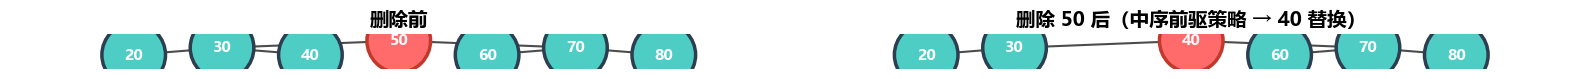

In [4]:
# ========== 题2-策略一：中序前驱 ==========
# 从原始 BST 拷贝一份
bst_pre = bst.copy()

print("原始 BST 中序遍历:", bst_pre.inorder())
print(f"\n删除结点 50 前，根结点 = {bst_pre.root.val}")

# 使用中序前驱策略删除
bst_pre.delete_with_predecessor(50)

print(f"删除结点 50 后，根结点 = {bst_pre.root.val}")
print("删除后中序遍历:", bst_pre.inorder())

# 绘制
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
draw_bst(bst, title="删除前", ax=axes[0], highlight_val=50)
draw_bst(bst_pre, title="删除 50 后（中序前驱策略 → 40 替换）", ax=axes[1], highlight_val=40)
plt.tight_layout()
plt.show()

**中序前驱策略结果：**

```
          40
        /    \
      30      70
     /       /  \
    20      60  80
```

根结点由 50 变为 **40**，40 原本位置的左子树（20）上移。

### 策略二：中序后继（Inorder Successor）

**定义**：中序后继是中序遍历中当前结点的**后一个**结点，即**右子树中的最小值**。

**删除步骤**：
1. 找到结点 50 的中序后继：右子树 (70) 中的最小值 → **60**
2. 用 60 的值替换 50 的值
3. 递归删除右子树中的 60（此时 60 是叶子结点，直接删除）

**结果**：根结点变为 60，右子树中 60 被删除。

原始 BST 中序遍历: [20, 30, 40, 50, 60, 70, 80]

删除结点 50 前，根结点 = 50
删除结点 50 后，根结点 = 60
删除后中序遍历: [20, 30, 40, 60, 70, 80]


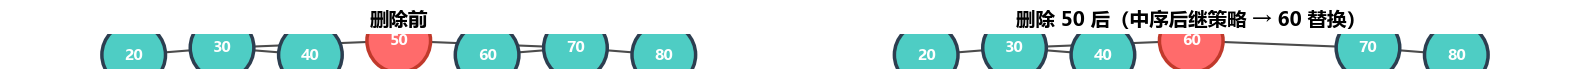

In [5]:
# ========== 题2-策略二：中序后继 ==========
# 从原始 BST 拷贝一份
bst_suc = bst.copy()

print("原始 BST 中序遍历:", bst_suc.inorder())
print(f"\n删除结点 50 前，根结点 = {bst_suc.root.val}")

# 使用中序后继策略删除
bst_suc.delete_with_successor(50)

print(f"删除结点 50 后，根结点 = {bst_suc.root.val}")
print("删除后中序遍历:", bst_suc.inorder())

# 绘制
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
draw_bst(bst, title="删除前", ax=axes[0], highlight_val=50)
draw_bst(bst_suc, title="删除 50 后（中序后继策略 → 60 替换）", ax=axes[1], highlight_val=60)
plt.tight_layout()
plt.show()

**中序后继策略结果：**

```
          60
        /    \
      30      70
     /  \       \
    20  40      80
```

根结点由 50 变为 **60**，60 原本在 70 的左孩子位置被移除。

### 两种策略对比

| 对比维度 | 中序前驱 | 中序后继 |
|----------|----------|----------|
| 替换值 | 左子树最大值 (40) | 右子树最小值 (60) |
| 结果根结点 | 40 | 60 |
| 树高度变化 | 不变 (仍为 3) | 不变 (仍为 3) |
| 左子树变化 | 40 被移除，20 上移 | 左子树完全不变 |
| 右子树变化 | 右子树完全不变 | 60 被移除 |

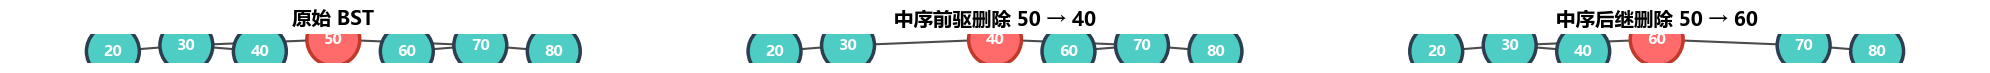

原始 BST    中序遍历: [20, 30, 40, 50, 60, 70, 80]
前驱策略删除 中序遍历: [20, 30, 40, 60, 70, 80]
后继策略删除 中序遍历: [20, 30, 40, 60, 70, 80]


In [6]:
# ========== 三种树并列对比 ==========
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

draw_bst(bst, title="原始 BST", ax=axes[0], highlight_val=50)
draw_bst(bst_pre, title="中序前驱删除 50 → 40", ax=axes[1], highlight_val=40)
draw_bst(bst_suc, title="中序后继删除 50 → 60", ax=axes[2], highlight_val=60)

plt.tight_layout()
plt.show()

print("=" * 50)
print("原始 BST    中序遍历:", bst.inorder())
print("前驱策略删除 中序遍历:", bst_pre.inorder())
print("后继策略删除 中序遍历:", bst_suc.inorder())
print("=" * 50)

---
## 题3：在真正的项目里使用的是哪个策略？

### 结论：实际项目中**两种策略都会使用**，但**中序后继（Inorder Successor）更常见**。

### 原因分析

#### 1. 随机数据下，后继策略更有利于保持平衡

在随机插入的 BST 中，使用**中序后继**（取右子树最小）删除结点，被删除的通常是叶子或接近叶子的结点（因为最小值的结点没有左孩子），这倾向于**不破坏树的结构**。

而中序前驱（取左子树最大）虽然也是叶子或接近叶子，但在**非随机/倾斜数据**中，前驱可能位于较深层。

#### 2. 多数标准库和教科书默认使用后继

| 语言/库 | 默认策略 |
|----------|----------|
| C++ `std::set` / `std::map` | 后继 |
| Java `TreeMap` / `TreeSet` | 后继 |
| Python 无内置 BST，第三方库 `bintrees` | 后继 |
| CLRS《算法导论》伪代码 | 后继 |
| Linux 内核红黑树 `rbtree` | 后继 |

#### 3. 与"删除-最小值"操作的一致性

BST 的许多高级操作（如 `pop_min`、合并两棵树）都依赖"找后继/最小值"操作。统一使用后继策略可以复用代码，减少维护成本。`delete_min` 是 BST 的基础原语，而中序后继删除本质上就是：`node.val = delete_min(node.right)`。

#### 4. 交替使用前驱和后继可以改善平衡性

有些高级实现会**随机**或**交替**使用前驱和后继（如 Symmetric BST），以避免长期偏向某一侧导致树退化。这在没有自平衡机制的普通 BST 中尤为重要。

### 总结

> **默认选择中序后继**（右子树最小值），因为它实现简单、与标准库一致、与"删除最小值"原语自然对应。如果树有退化倾向，可交替使用前驱和后继来缓解。在自平衡树（AVL、红黑树）中，删除后会自动再平衡，因此选择哪个策略对最终结构影响不大——此时纯粹是**工程习惯**问题，大多数代码库选择后继。

In [7]:
# ========== 补充：展示交替策略的优势 ==========
import random

def simulate_deletions(delete_strategy, rounds=100):
    """模拟多次随机插入后删除根结点，记录树的平均深度"""
    depths = []
    for _ in range(rounds):
        bst = BST()
        nums = random.sample(range(1, 1000), 63)  # 63 个随机数，6 层满二叉树
        for n in nums:
            bst.insert(n)
        root_val = bst.root.val
        if delete_strategy == 'predecessor':
            bst.delete_with_predecessor(root_val)
        elif delete_strategy == 'successor':
            bst.delete_with_successor(root_val)
        else:  # alternating
            if _ % 2 == 0:
                bst.delete_with_predecessor(root_val)
            else:
                bst.delete_with_successor(root_val)
        depths.append(get_tree_depth(bst.root))
    return sum(depths) / len(depths)

print("模拟 100 轮随机插入 63 个元素后删除根结点：")
print(f"  纯前驱策略  平均深度: {simulate_deletions('predecessor'):.2f}")
print(f"  纯后继策略  平均深度: {simulate_deletions('successor'):.2f}")
print(f"  交替策略    平均深度: {simulate_deletions('alternating'):.2f}")
print("\n注：在随机数据下，两种纯策略表现接近。交替策略在某些倾斜场景下更优。")

模拟 100 轮随机插入 63 个元素后删除根结点：
  纯前驱策略  平均深度: 11.64
  纯后继策略  平均深度: 11.69
  交替策略    平均深度: 11.48

注：在随机数据下，两种纯策略表现接近。交替策略在某些倾斜场景下更优。
